In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("Train.csv") 

In [3]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])


In [5]:
# Compute Correlation Matrix
corr_matrix = numeric_cols.corr()


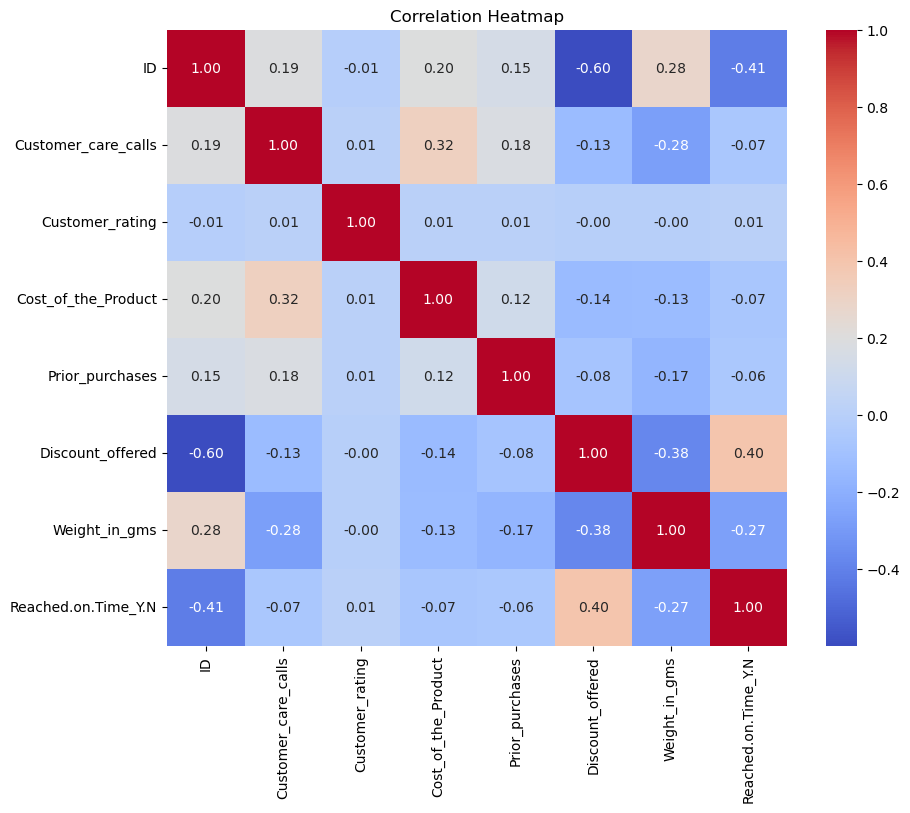

In [6]:
#plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


- Strong positive correlation (close to +1): features move together.
- Strong negative correlation (close to –1): features move oppositely.
- Near zero: no linear relationship.
This helps you decide which features to keep, combine, or regularize. For example, if Discount_offered and Cost_of_the_Product are highly correlated, you might regularize one to avoid multicollinearity.


Feature Engineering

In [12]:
# Create Delivery_Status label from 'Reached.on.Time_Y.N'
df['Delivery_Status'] = df['Reached.on.Time_Y.N'].map({1: 'On Time', 0: 'Delayed'})


In [13]:
#Cost Category
df['Cost_Category'] = pd.cut(df['Cost_of_the_Product'],
                             bins=[0, 100, 200, float('inf')],
                             labels=['Low', 'Medium', 'High'])


In [14]:
# Customer Loyalty Score
df['Loyalty_Score'] = df['Prior_purchases'] * df['Customer_rating']


In [15]:
#High Discount Flag
df['High_Discount'] = df['Discount_offered'].apply(lambda x: 1 if x > 30 else 0)


In [18]:
#Shipping Efficiency Index
def efficiency(row):
    if row['Mode_of_Shipment'] == 'Flight':
        return row['Weight_in_gms'] / 1.5
    elif row['Mode_of_Shipment'] == 'Road':
        return row['Weight_in_gms'] / 2.5
    else:
        return row['Weight_in_gms'] / 3.5

df['Efficiency_Index'] = df.apply(efficiency, axis=1)





In [19]:
df = pd.get_dummies(df, columns=['Mode_of_Shipment', 'Product_importance',
                                 'Warehouse_block', 'Gender'], drop_first=True)


In [20]:
#Interaction Feature: Rating × Discount

df['Rating_Discount_Interaction'] = df['Customer_rating'] * df['Discount_offered']


In [21]:
#Normalized Weight
df['Normalized_Weight'] = (df['Weight_in_gms'] - df['Weight_in_gms'].min()) / \
                          (df['Weight_in_gms'].max() - df['Weight_in_gms'].min())


- They help our model learn patterns more easily.
- They reduce noise and improve generalization.
- They prepare our data for regularization and regression.


In [33]:
#Feature Engineering – Create New Features
# Cost per gram
df['Cost_per_gram'] = df['Cost_of_the_Product'] / df['Weight_in_gms']

# Interaction: rating × prior purchases
df['Rating_x_Purchases'] = df['Customer_rating'] * df['Prior_purchases']

# Discount ratio
df['Discount_ratio'] = df['Discount_offered'] / df['Cost_of_the_Product']

# Loyalty-adjusted efficiency
df['Loyalty_Efficiency'] = df['Loyalty_Score'] * df['Efficiency_Index']



In [34]:
#Imputation – Fill Missing Values
# Check for missing values
print(df.isnull().sum())

# Fill numerical columns with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


ID                             0
Customer_care_calls            0
Customer_rating                0
Cost_of_the_Product            0
Prior_purchases                0
Discount_offered               0
Weight_in_gms                  0
Reached.on.Time_Y.N            0
Delivery_Status                0
Cost_Category                  0
Loyalty_Score                  0
High_Discount                  0
Efficiency_Index               0
Mode_of_Shipment_Road          0
Mode_of_Shipment_Ship          0
Product_importance_low         0
Product_importance_medium      0
Warehouse_block_B              0
Warehouse_block_C              0
Warehouse_block_D              0
Warehouse_block_F              0
Gender_M                       0
Rating_Discount_Interaction    0
Normalized_Weight              0
Cost_per_gram                  0
Rating_x_Purchases             0
Discount_ratio                 0
Loyalty_Efficiency             0
dtype: int64


In [35]:
# Interpolation – Last Missing Value
# Interpolate Weight if missing
df['Weight_in_gms'] = df['Weight_in_gms'].interpolate(method='linear')


In [36]:
#Encoding & Scaling
from sklearn.preprocessing import StandardScaler

scale_cols = ['Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[scale_cols]), columns=[col + '_scaled' for col in scale_cols])

df = pd.concat([df, df_scaled], axis=1)


In [44]:
#Feature Selection
X = df.drop(['Reached.on.Time_Y.N', 'ID'], axis=1)
y = df['Reached.on.Time_Y.N']


In [46]:
X = X.select_dtypes(include='number')


In [48]:
model = LogisticRegression(max_iter=5000)


In [49]:
model = LogisticRegression(solver='liblinear', max_iter=1000)


<Axes: >

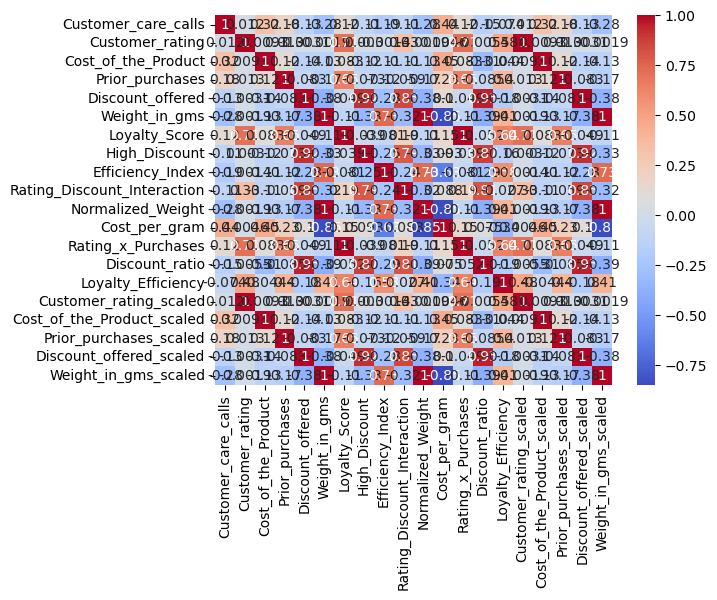

In [50]:
import seaborn as sns
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')


In [51]:
['Customer_care_calls', 'Customer_rating', 'Discount_offered', 'High_Discount',
 'Customer_rating_scaled', 'Cost_of_the_Product_scaled',
 'Prior_purchases_scaled', 'Weight_in_gms_scaled']


['Customer_care_calls',
 'Customer_rating',
 'Discount_offered',
 'High_Discount',
 'Customer_rating_scaled',
 'Cost_of_the_Product_scaled',
 'Prior_purchases_scaled',
 'Weight_in_gms_scaled']

In [52]:
['Customer_care_calls', 'Customer_rating', 'Discount_offered', 'High_Discount',
 'Normalized_Weight', 'Cost_per_gram', 'Discount_ratio',
 'Customer_rating_scaled', 'Prior_purchases_scaled', 'Weight_in_gms_scaled']


['Customer_care_calls',
 'Customer_rating',
 'Discount_offered',
 'High_Discount',
 'Normalized_Weight',
 'Cost_per_gram',
 'Discount_ratio',
 'Customer_rating_scaled',
 'Prior_purchases_scaled',
 'Weight_in_gms_scaled']

In [55]:
df['Customer_Effort_Score'] = df['Customer_care_calls'] + df['Customer_rating'] + df['Prior_purchases']

df['Discount_per_gram'] = df['Discount_offered'] / df['Weight_in_gms']
df['Loyalty_Rating_Interaction'] = df['Loyalty_Score'] * df['Customer_rating_scaled']
df['Cost_Efficiency_Ratio'] = df['Cost_of_the_Product'] / df['Efficiency_Index']

df['Discount_Impact'] = df['Discount_offered_scaled'] * df['High_Discount']
df['Shipment_Score'] = df['Mode_of_Shipment_Road'] + df['Mode_of_Shipment_Ship']
df['Warehouse_Diversity'] = df[['Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F']].sum(axis=1)


In [56]:
#Train-Validation-Test Split
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


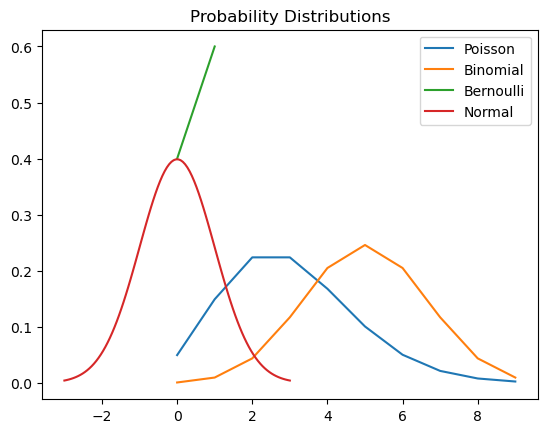

In [57]:
#Plot Probability Distributions
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson, binom, bernoulli, norm

x = np.arange(0, 10)

plt.plot(x, poisson.pmf(x, mu=3), label='Poisson')
plt.plot(x, binom.pmf(x, n=10, p=0.5), label='Binomial')
plt.plot([0, 1], bernoulli.pmf([0, 1], p=0.6), label='Bernoulli')
x_norm = np.linspace(-3, 3, 100)
plt.plot(x_norm, norm.pdf(x_norm), label='Normal')

plt.legend()
plt.title("Probability Distributions")
plt.show()


In [30]:
#Simple Linear Regression
from sklearn.linear_model import LinearRegression

X_lin = df[['Customer_rating']]
y_lin = df['Cost_of_the_Product']

lr = LinearRegression()
lr.fit(X_lin, y_lin)

print("Slope:", lr.coef_[0])
print("Intercept:", lr.intercept_)






Slope: 0.31516884507278314
Intercept: 209.2543095898737


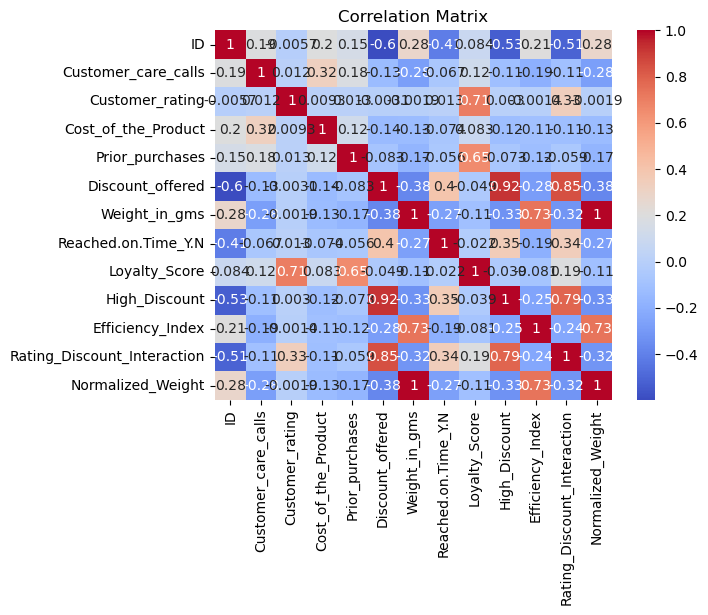

In [31]:
# Correlation Matrix
import seaborn as sns

corr_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()






In [58]:
from sklearn.preprocessing import StandardScaler

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Scale numeric columns
scale_cols = ['Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[scale_cols]), columns=[col + '_scaled' for col in scale_cols])
df = pd.concat([df, df_scaled], axis=1)


In [63]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
# Predict on test set
y_pred = model.predict(X_test)


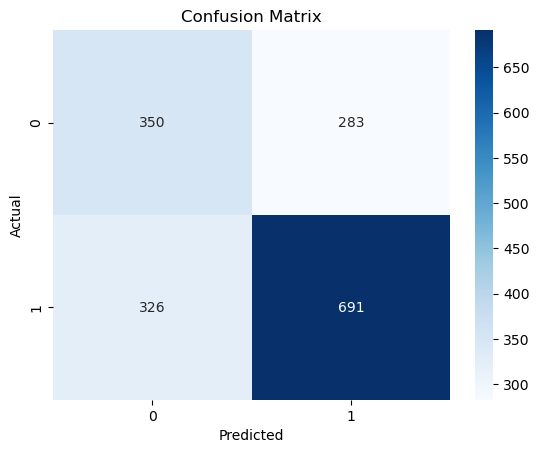

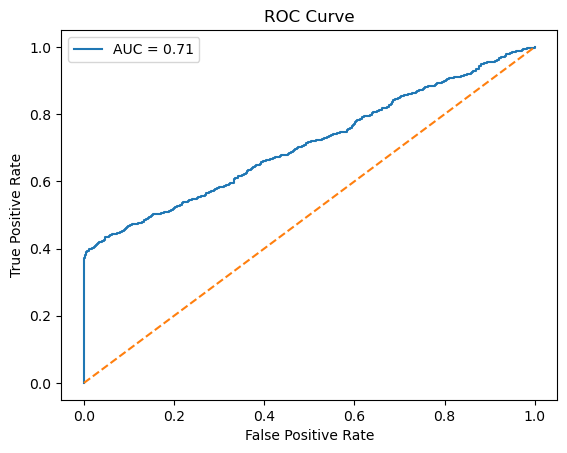

In [64]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.92      0.68       633
           1       0.91      0.50      0.65      1017

    accuracy                           0.66      1650
   macro avg       0.72      0.71      0.66      1650
weighted avg       0.77      0.66      0.66      1650



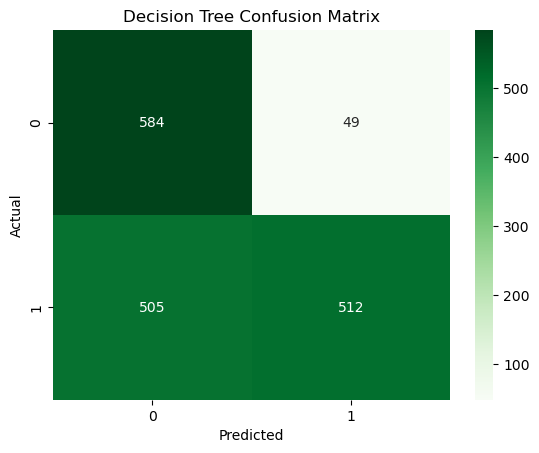

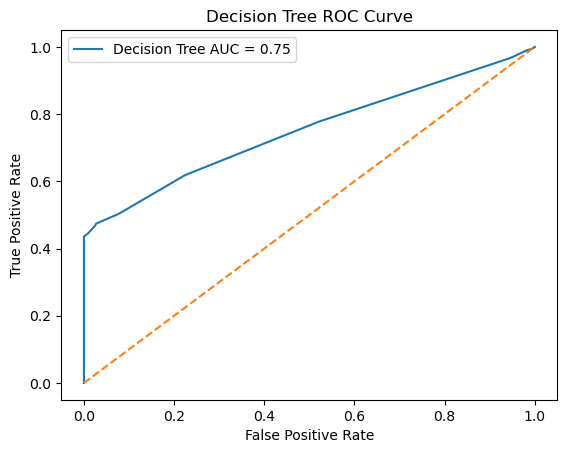

In [66]:
# Decision Tree Classifier with Evaluation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree AUC = {roc_auc_dt:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("Decision Tree ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()



Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.68      0.61       633
           1       0.77      0.66      0.71      1017

    accuracy                           0.67      1650
   macro avg       0.66      0.67      0.66      1650
weighted avg       0.68      0.67      0.67      1650



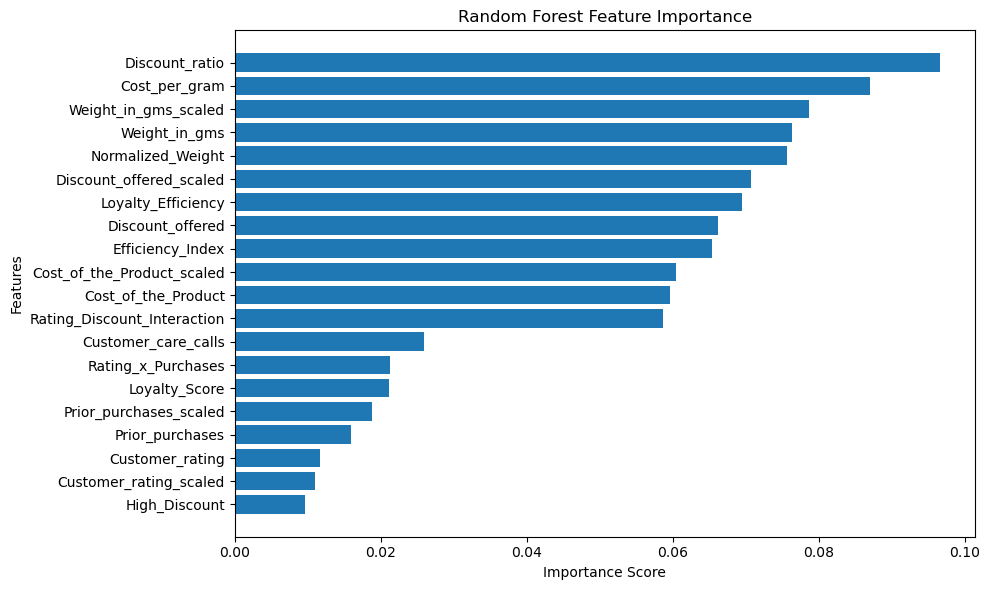

In [69]:
#Random Forest Classifier with Feature Importance
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# Feature Importance Plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.barh(X_train.columns[indices], importances[indices])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


 Variance Inflation Factor (VIF)


In [70]:
from sklearn.metrics import accuracy_score

acc_log = accuracy_score(y_test, y_pred)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_log:.2f}")
print(f"Decision Tree Accuracy: {acc_dt:.2f}")
print(f"Random Forest Accuracy: {acc_rf:.2f}")


Logistic Regression Accuracy: 0.63
Decision Tree Accuracy: 0.66
Random Forest Accuracy: 0.67


In [72]:
# Check for constant columns
constant_cols = [col for col in X_train.columns if X_train[col].nunique() == 1]
print("Constant columns:", constant_cols)

# Check for duplicate columns
print("Duplicate columns:", X_train.T.duplicated().sum())


Constant columns: []
Duplicate columns: 1


In [73]:
# Identify duplicate columns
duplicates = X_train.T[X_train.T.duplicated()].index.tolist()
print("Duplicate column(s):", duplicates)

# Drop the duplicate column(s)
X_vif = X_train.drop(columns=duplicates)


Duplicate column(s): ['Rating_x_Purchases']


In [79]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(X):
    X_const = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    return vif_data

# Start with cleaned X_train
X_clean = X_train.drop(columns=['Rating_x_Purchases'])

# Iteratively drop features with infinite VIF
while True:
    vif_df = calculate_vif(X_clean)
    if vif_df['VIF'].isin([float('inf')]).any():
        drop_feature = vif_df.loc[vif_df['VIF'] == float('inf'), 'Feature'].values[0]
        print(f"Dropping feature with infinite VIF: {drop_feature}")
        X_clean = X_clean.drop(columns=[drop_feature])
    else:
        break

# Final VIF table
print("Final VIF values:")
print(calculate_vif(X_clean))




Multiple Linear Regression Pipeline

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [86]:
# Use your final cleaned feature set after VIF filtering
X_final = X_clean.drop(columns=[
    'Discount_offered_scaled',
    'Discount_ratio',
    'Loyalty_Score'
])  # Drop high-VIF features

# Align target variable
y_aligned = y.loc[X_final.index]

# Train-test split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_final, y_aligned, test_size=0.2, random_state=42
)


In [87]:
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)


LinearRegression()

In [88]:
y_pred_lr = lr_model.predict(X_test_lr)

mse = mean_squared_error(y_test_lr, y_pred_lr)
r2 = r2_score(y_test_lr, y_pred_lr)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error: 0.19
R² Score: 0.20


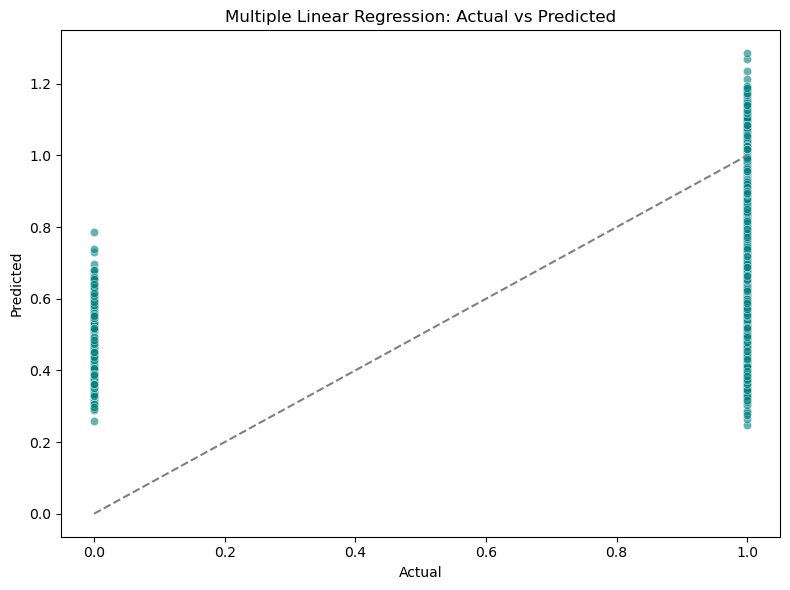

In [89]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_lr, y=y_pred_lr, alpha=0.6, color='teal')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()
